In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.proportion import proportion_confint
import warnings
warnings.filterwarnings('ignore')

sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (12, 5)

print("Libraries imported ✅")

Libraries imported ✅


In [2]:
df = pd.read_csv('C:/Users/Yashwanth u/Desktop/Data_projects/ab-testing/data/raw/ab_data_clean.csv')

control   = df[df['group'] == 'control']
treatment = df[df['group'] == 'treatment']

print(f"Control Users:   {len(control):,}")
print(f"Treatment Users: {len(treatment):,}")

Control Users:   145,274
Treatment Users: 145,310


# Hypothesis Testing

NULL HYPOTHESIS (H0):
"The new page has NO effect on conversion rate"
"New page conversion = Old page conversion"
→ Any difference we see is just random chance

ALTERNATIVE HYPOTHESIS (H1):
"The new page DOES affect conversion rate"
"New page conversion ≠ Old page conversion"
→ The difference is real and meaningful

Significance Level → α = 0.05 (95% confidence)

Decision Rule:
→ If p-value < 0.05 → Reject H0 → Real difference exists
→ If p-value > 0.05 → Fail to reject H0 → No real difference

In [3]:
# Conversions and users per group
control_conv   = control['converted'].sum()
treatment_conv = treatment['converted'].sum()

control_n   = len(control)
treatment_n = len(treatment)

control_rate   = control['converted'].mean()
treatment_rate = treatment['converted'].mean()

print("=" * 50)
print("📊 KEY METRICS")
print("=" * 50)
print(f"Control   → {control_conv:,} / {control_n:,} = {control_rate*100:.4f}%")
print(f"Treatment → {treatment_conv:,} / {treatment_n:,} = {treatment_rate*100:.4f}%")
print(f"Difference → {(treatment_rate - control_rate)*100:.4f}%")
print(f"Relative Change → {((treatment_rate - control_rate)/control_rate)*100:.2f}%")
print("=" * 50)

📊 KEY METRICS
Control   → 17,489 / 145,274 = 12.0386%
Treatment → 17,264 / 145,310 = 11.8808%
Difference → -0.1578%
Relative Change → -1.31%


In [4]:
# Two proportion Z-test
# Tests if two conversion rates are significantly different

conversions = np.array([control_conv, treatment_conv])
nobs        = np.array([control_n, treatment_n])

z_stat, p_value = proportions_ztest(conversions, nobs)

print("=" * 50)
print("🔬 Z-TEST RESULTS")
print("=" * 50)
print(f"Z-Statistic : {z_stat:.4f}")
print(f"P-Value     : {p_value:.4f}")
print(f"\nSignificance Level (α): 0.05")
print("=" * 50)

if p_value < 0.05:
    print("\n✅ REJECT Null Hypothesis")
    print("→ Difference IS statistically significant")
    print("→ New page has REAL effect on conversions")
else:
    print("\n❌ FAIL TO REJECT Null Hypothesis")
    print("→ Difference is NOT statistically significant")
    print("→ New page has NO real effect on conversions")
print("=" * 50)

🔬 Z-TEST RESULTS
Z-Statistic : 1.3109
P-Value     : 0.1899

Significance Level (α): 0.05

❌ FAIL TO REJECT Null Hypothesis
→ Difference is NOT statistically significant
→ New page has NO real effect on conversions


In [5]:
# 95% Confidence Interval for each group

control_ci   = proportion_confint(control_conv, control_n, alpha=0.05)
treatment_ci = proportion_confint(treatment_conv, treatment_n, alpha=0.05)

print("=" * 55)
print("📊 95% CONFIDENCE INTERVALS")
print("=" * 55)
print(f"Control   → ({control_ci[0]*100:.4f}%, {control_ci[1]*100:.4f}%)")
print(f"Treatment → ({treatment_ci[0]*100:.4f}%, {treatment_ci[1]*100:.4f}%)")
print("=" * 55)
print("\n📌 Interpretation:")
print("If confidence intervals OVERLAP → no real difference")
print("If confidence intervals DON'T overlap → real difference")

# Check overlap
if control_ci[0] < treatment_ci[1] and treatment_ci[0] < control_ci[1]:
    print("\n⚠️ Intervals OVERLAP → supports no significant difference")
else:
    print("\n✅ Intervals DON'T overlap → significant difference exists")

📊 95% CONFIDENCE INTERVALS
Control   → (11.8713%, 12.2060%)
Treatment → (11.7144%, 12.0472%)

📌 Interpretation:
If confidence intervals OVERLAP → no real difference
If confidence intervals DON'T overlap → real difference

⚠️ Intervals OVERLAP → supports no significant difference


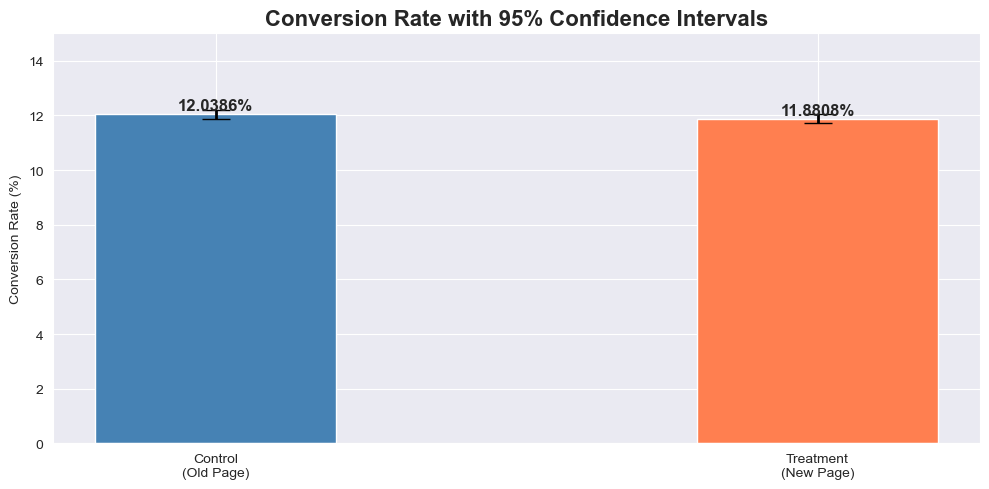

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

groups = ['Control\n(Old Page)', 'Treatment\n(New Page)']
rates  = [control_rate*100, treatment_rate*100]
errors = [
    (control_ci[1] - control_ci[0])*100/2,
    (treatment_ci[1] - treatment_ci[0])*100/2
]

colors = ['steelblue', 'coral']
bars = ax.bar(groups, rates, color=colors,
              width=0.4, yerr=errors,
              capsize=10, error_kw={'linewidth': 2})

for bar, val in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.15,
            f'{val:.4f}%', ha='center',
            fontweight='bold', fontsize=12)

ax.set_title('Conversion Rate with 95% Confidence Intervals',
             fontsize=16, fontweight='bold')
ax.set_ylabel('Conversion Rate (%)')
ax.set_ylim(0, 15)
plt.tight_layout()
plt.savefig('C:/Users/Yashwanth u/Desktop/Data_projects/ab-testing/data/raw/06_confidence_intervals.png', dpi=150)
plt.show()

In [7]:
from statsmodels.stats.power import NormalIndPower

# Were we able to detect a real difference if one existed?
effect_size = abs(treatment_rate - control_rate) / np.sqrt(
    (control_rate + treatment_rate) / 2 *
    (1 - (control_rate + treatment_rate) / 2)
)

power_analysis = NormalIndPower()
power = power_analysis.solve_power(
    effect_size=effect_size,
    nobs1=control_n,
    alpha=0.05,
    ratio=1
)

print("=" * 50)
print("⚡ POWER ANALYSIS")
print("=" * 50)
print(f"Effect Size     : {effect_size:.6f}")
print(f"Sample Size     : {control_n:,} per group")
print(f"Statistical Power: {power:.4f} ({power*100:.2f}%)")
print("=" * 50)
print("\n📌 Interpretation:")
print("Power > 80% → Test can reliably detect real differences")
print("Power < 80% → Test might miss real differences")
if power >= 0.8:
    print(f"\n✅ Power = {power*100:.2f}% → Test is reliable")
else:
    print(f"\n⚠️ Power = {power*100:.2f}% → Test may not be reliable")

⚡ POWER ANALYSIS
Effect Size     : 0.004864
Sample Size     : 145,274 per group
Statistical Power: 0.2587 (25.87%)

📌 Interpretation:
Power > 80% → Test can reliably detect real differences
Power < 80% → Test might miss real differences

⚠️ Power = 25.87% → Test may not be reliable


In [8]:
print("=" * 55)
print("💰 BUSINESS IMPACT ANALYSIS")
print("=" * 55)

# Assumptions
monthly_visitors  = 500000
avg_order_value   = 50  # dollars

# Current performance (old page)
current_conv      = control_rate
current_revenue   = monthly_visitors * current_conv * avg_order_value

# New page performance
new_conv          = treatment_rate
new_revenue       = monthly_visitors * new_conv * avg_order_value

revenue_diff      = new_revenue - current_revenue

print(f"Monthly Visitors (assumed) : {monthly_visitors:,}")
print(f"Average Order Value        : ${avg_order_value}")
print(f"\nOld Page Conv Rate         : {current_conv*100:.4f}%")
print(f"New Page Conv Rate         : {new_conv*100:.4f}%")
print(f"\nOld Page Monthly Revenue   : ${current_revenue:,.2f}")
print(f"New Page Monthly Revenue   : ${new_revenue:,.2f}")
print(f"Revenue Difference         : ${revenue_diff:,.2f}")
print(f"\nAnnual Revenue Impact      : ${revenue_diff*12:,.2f}")
print("=" * 55)

if revenue_diff < 0:
    print(f"\n🚨 Launching new page would cost")
    print(f"   ${abs(revenue_diff):,.2f}/month = ${abs(revenue_diff*12):,.2f}/year")
else:
    print(f"\n✅ New page would generate")
    print(f"   ${revenue_diff:,.2f}/month extra revenue")

💰 BUSINESS IMPACT ANALYSIS
Monthly Visitors (assumed) : 500,000
Average Order Value        : $50

Old Page Conv Rate         : 12.0386%
New Page Conv Rate         : 11.8808%

Old Page Monthly Revenue   : $3,009,657.61
New Page Monthly Revenue   : $2,970,201.64
Revenue Difference         : $-39,455.97

Annual Revenue Impact      : $-473,471.70

🚨 Launching new page would cost
   $39,455.97/month = $473,471.70/year


In [9]:
print("=" * 60)
print("🏁 FINAL A/B TEST VERDICT")
print("=" * 60)
print(f"\nControl Conv Rate   : {control_rate*100:.4f}%")
print(f"Treatment Conv Rate : {treatment_rate*100:.4f}%")
print(f"Difference          : {(treatment_rate-control_rate)*100:.4f}%")
print(f"P-Value             : {p_value:.4f}")
print(f"Significance Level  : 0.05")
print("\n" + "=" * 60)

if p_value < 0.05:
    print("VERDICT: REJECT NULL HYPOTHESIS")
    print("→ Real difference exists")
    print("→ Recommend launching new page")
else:
    print("VERDICT: FAIL TO REJECT NULL HYPOTHESIS")
    print("→ No statistically significant difference")
    print("→ DO NOT launch new page")
    print("→ New page shows NO improvement")
    print("→ Stick with old page")

print("\n💡 BUSINESS RECOMMENDATION:")
print("The new landing page does not show statistically")
print("significant improvement over the old page.")
print("Recommend keeping the old page and investing")
print("design resources elsewhere.")
print("=" * 60)

🏁 FINAL A/B TEST VERDICT

Control Conv Rate   : 12.0386%
Treatment Conv Rate : 11.8808%
Difference          : -0.1578%
P-Value             : 0.1899
Significance Level  : 0.05

VERDICT: FAIL TO REJECT NULL HYPOTHESIS
→ No statistically significant difference
→ DO NOT launch new page
→ New page shows NO improvement
→ Stick with old page

💡 BUSINESS RECOMMENDATION:
The new landing page does not show statistically
significant improvement over the old page.
Recommend keeping the old page and investing
design resources elsewhere.
